In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import os

In [ ]:
base_path = "/content/drive/My Drive/dev"
img_base_path = "/content/drive/My Drive/yelp/photos"
train_path = f"{base_path}/train_data.csv"
test_path = f"{base_path}/test_data.csv"

In [ ]:
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_train['image_path'] = df_train['photo_id'].apply(lambda x: f"{img_base_path}/{x}")
df_test['image_path'] = df_test['photo_id'].apply(lambda x: f"{img_base_path}/{x}")
print(df_train['image_path'].head())

0    /content/drive/My Drive/yelp/photos/38uF8Xq04G...
1    /content/drive/My Drive/yelp/photos/VXpYAvJJFx...
2    /content/drive/My Drive/yelp/photos/IkXGsVerw1...
3    /content/drive/My Drive/yelp/photos/VGrj-6peae...
4    /content/drive/My Drive/yelp/photos/WbdvpVcuXu...
Name: image_path, dtype: object


In [ ]:
label_encoder = LabelEncoder()
df_train['label_str'] = label_encoder.fit_transform(df_train['label']).astype(str)
df_test['label_str'] = label_encoder.transform(df_test['label']).astype(str)

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, validation_split=0.2)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='image_path',
    y_col='label_str',
    target_size=(224, 224),
    class_mode='categorical',
    subset='training',
    batch_size=32,
    shuffle=True
)
val_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='image_path',
    y_col='label_str',
    target_size=(224, 224),
    class_mode='categorical',
    subset='validation',
    batch_size=32,
    shuffle=True
)

Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 159995 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 159995 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
print(df_train['photo_id'].head())

0    38uF8Xq04Gitx84x_o24Tw
1    VXpYAvJJFxA39v3ytyAHJg
2    IkXGsVerw1GXPenUe5WEkA
3    VGrj-6peaeoytB8jSwOq1g
4    WbdvpVcuXuBz4FYjmf8zZA
Name: photo_id, dtype: object


In [ ]:
  df_train['image_path'] = df_train['photo_id'].apply(lambda x: f"{img_base_path}/{x}.jpg")
  df_test['image_path'] = df_test['photo_id'].apply(lambda x: f"{img_base_path}/{x}.jpg")


In [ ]:
import os
print(df_train['image_path'].iloc[0])
print("Exists:", os.path.exists(df_train['image_path'].iloc[0]))


/content/drive/My Drive/yelp/photos/38uF8Xq04Gitx84x_o24Tw.jpg
Exists: True


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, validation_split=0.2)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='image_path',
    y_col='label_str',
    target_size=(224, 224),
    class_mode='categorical',
    subset='training',
    batch_size=32,
    shuffle=True
)
val_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='image_path',
    y_col='label_str',
    target_size=(224, 224),
    class_mode='categorical',
    subset='validation',
    batch_size=32,
    shuffle=True
)

Found 44277 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 104649 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


Found 11069 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 104649 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
num_classes = max(train_generator.classes) + 1
base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = True

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,
    steps_per_epoch=10,
    validation_steps=5
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 840s 84s/step - accuracy: 0.5406 - loss: 1.1737 - val_accuracy: 0.7688 - val_loss: 0.6863


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
df_val_fast = df_test.sample(n=200, random_state=42).copy()
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator_fast = val_datagen.flow_from_dataframe(
    dataframe=df_val_fast,
    x_col='image_path',
    y_col='label_str',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)
y_pred_probs = model.predict(val_generator_fast, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator_fast.classes
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
try:
    present_classes = np.unique(y_true)
    present_class_names = label_encoder.inverse_transform(present_classes)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=present_class_names))
except Exception as e:
    print(" Error in classification report:", e)


Found 52 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 148 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 15s/step
Confusion Matrix:
[[ 1  1  4  0]
 [ 0 23  0  0]
 [ 0  1 19  0]
 [ 0  0  3  0]]

Classification Report:
              precision    recall  f1-score   support

       drink       1.00      0.17      0.29         6
        food       0.92      1.00      0.96        23
      inside       0.73      0.95      0.83        20
        menu       0.00      0.00      0.00         3

    accuracy                           0.83        52
   macro avg       0.66      0.53      0.52        52
weighted avg       0.80      0.83      0.77        52



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


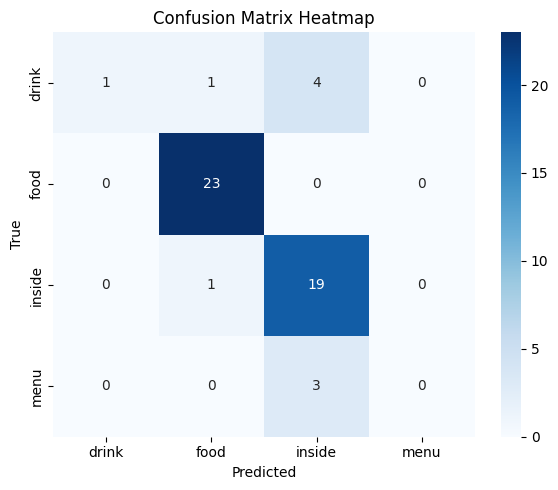

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
present_classes = np.unique(y_true)
present_class_names = label_encoder.inverse_transform(present_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_class_names,
            yticklabels=present_class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()


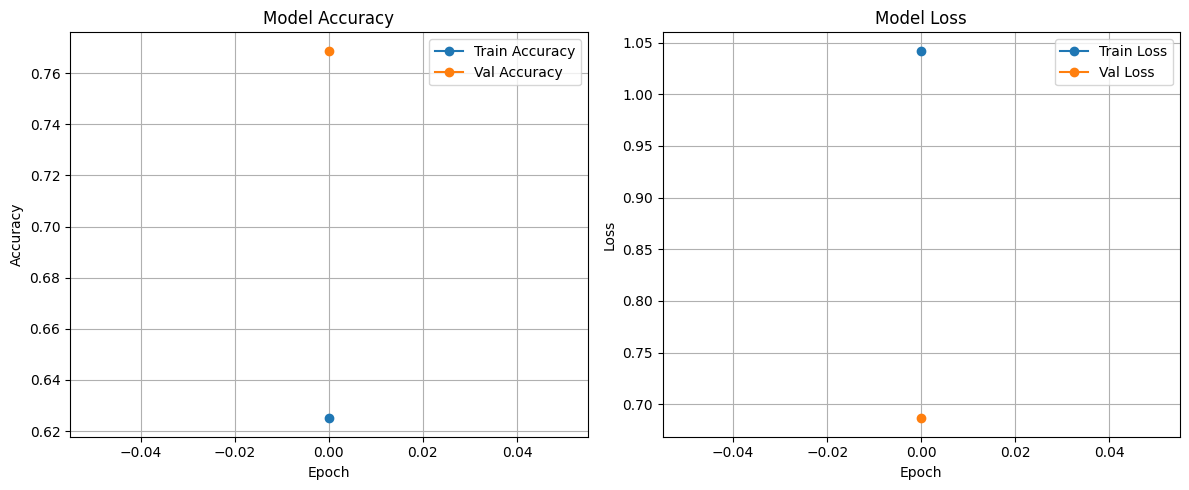

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
